# Seleccion de Variables con Step Forward


En el presente notebook se generan y se evalúan los siguientes modelos.

* Regresión lineal
* Regresion lineal regularizada
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica

El preprocesamiento principal se realiza mediante una seleccion de variables utilizando step forwarding para regresion lineal. 

In [64]:
library(MASS)
library(leaps)
library(glmnet)
library(pracma)
library(raster)
library(ggplot2)
source("Utils.R")

In [3]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

StScaler <- import("sklearn.preprocessing", convert = FALSE)$StandardScaler
MMScaler <- import("sklearn.preprocessing", convert = FALSE)$MinMaxScaler

In [4]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y

hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

### Mediante KFold con K=40 elegimos la mejor cantidad de variables (que no sobreajuste)

In [26]:
setSeed()

n = nrow(TRAIN_X)
k = 40

nvmax=n-n/k
resultados <- matrix(0, nrow=k, ncol = nvmax-1)

X = TRAIN_X

indices = obtener_indices_kfold(n, k)
a=1
for(i in indices){
    DF_train = X[-i,]
    DF_train$Y = TRAIN_Y[-i]

    DF_test = X[i,]
    DF_test$Y = TRAIN_Y[i]
    
    forw <- regsubsets(Y~., data=DF_train, method = "forward", nvmax=nvmax-1)
    
    for(j in 1:(nvmax-1)){
        Y_pred = predict(forw, DF_test, id=j)
        resultados[[a, j]] = mean( (DF_test$Y - Y_pred)^2 )
    }
    a=a+1
    message(progreso(a, 1:k))
}

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 7.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 10 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 12.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 15 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 17.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = 

In [68]:
result <- as.data.frame(resultados)
colnames(result) <- seq(1, 155)

In [92]:
a <- as.data.frame(t(apply(result, 2, summary)))
a$ind = seq(1,155)
colnames(a) <- c("min", "q1", "median", "mean", "q3", "max", "ind")

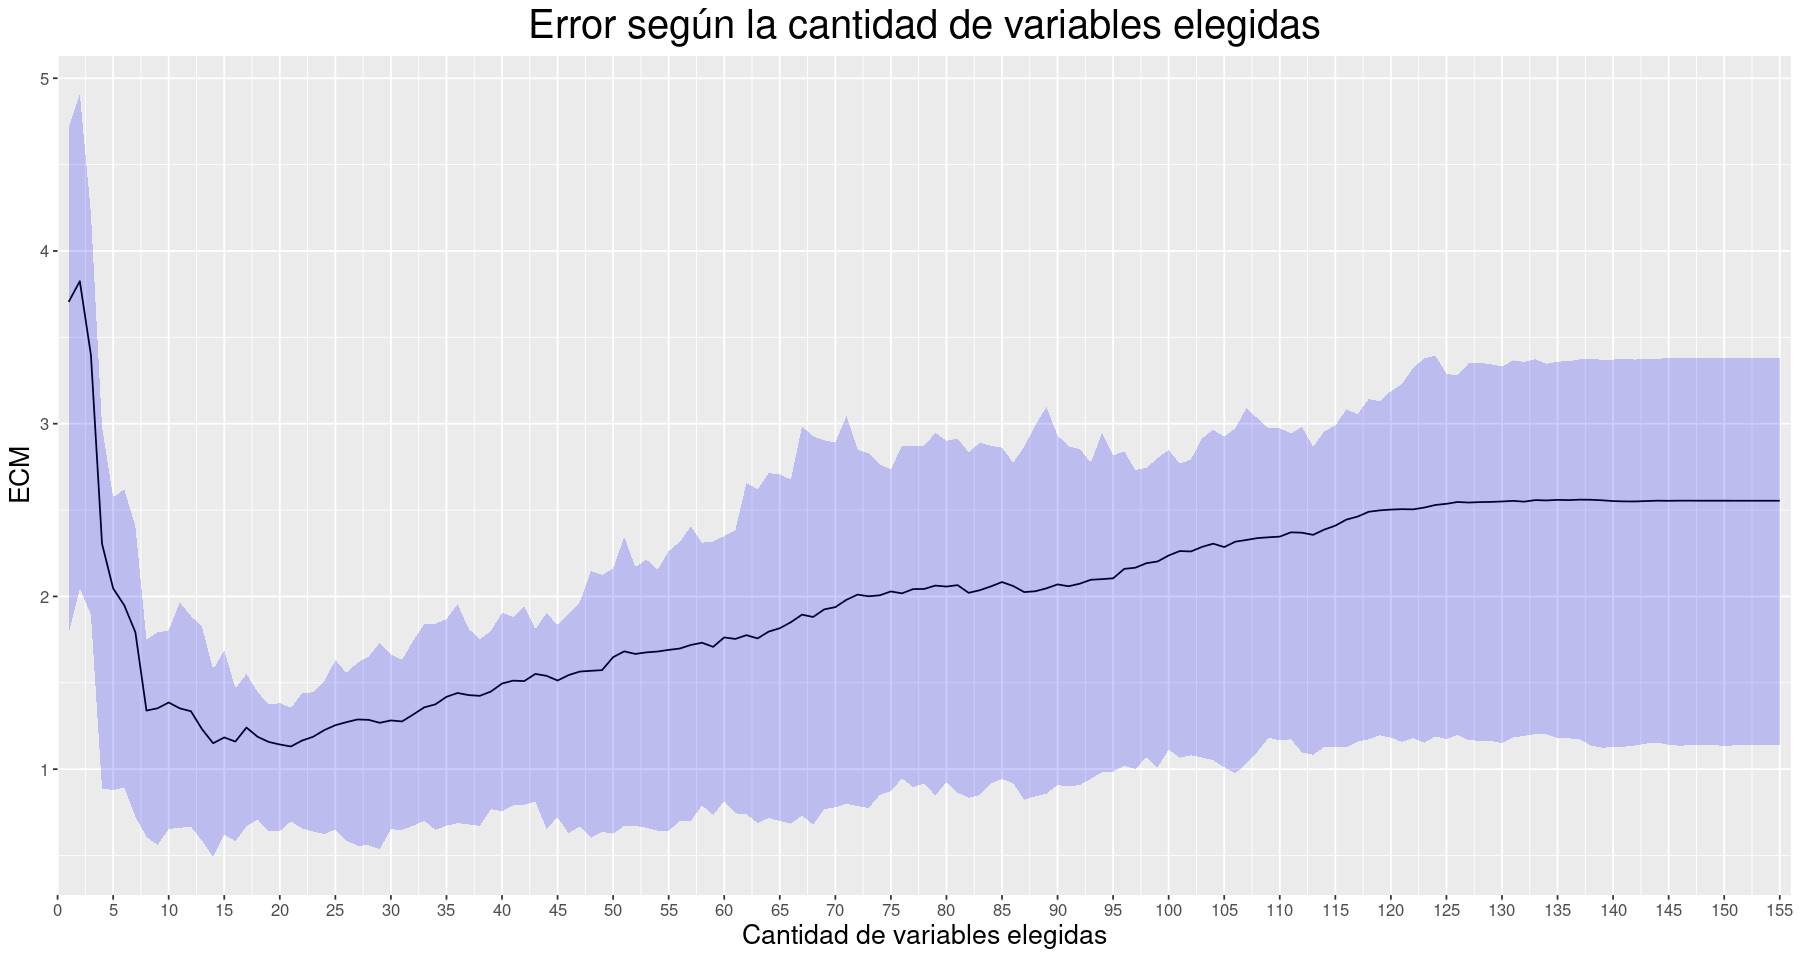

In [101]:
options(repr.plot.width=15, repr.plot.height=8)
theme_update(plot.title = element_text(hjust = 0.5, size = 24),
                          axis.text=element_text(size=10),
                          axis.title=element_text(size=16))

ggplot(a, aes(x=ind, y=mean)) +
    geom_line() +
    geom_ribbon(aes(ymin=q1, ymax=q3), fill="blue", alpha=0.2) +
    scale_x_continuous(breaks = seq(0, 155, by=5), expand = c(0, 1))+
    ggtitle("Error según la cantidad de variables elegidas") + 
    xlab("Cantidad de variables elegidas") + ylab("ECM")

Vemos en este gráfico que entre 10 y 30 el error se comporta de forma similar, para luego empezar a overfittear, por lo que haremos ahora un gráfico más detallado sobre esta zona.

In [102]:
setSeed()

n = nrow(TRAIN_X)
k = n

nvmax=30
nvmin=10
resultados <- matrix(0, nrow=k, ncol = nvmax)

X = TRAIN_X

indices = obtener_indices_kfold(n, k)
a=1
for(i in indices){
    DF_train = X[-i,]
    DF_train$Y = TRAIN_Y[-i]

    DF_test = X[i,]
    DF_test$Y = TRAIN_Y[i]
    
    forw <- regsubsets(Y~., data=DF_train, method = "forward", nvmax=nvmax)
    
    for(j in nvmin:nvmax){
        Y_pred = predict(forw, DF_test, id=j)
        resultados[[a, j]] = mean( (DF_test$Y - Y_pred)^2 )
    }
    a=a+1
    message(progreso(a, 1:k))
}

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 1.2 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 1.9 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 2.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 3.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 3.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 4.4 %

Warning message in leaps.setup(x, y, wt = wt, nbest 

El progreso es del 33.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 33.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 34.4 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 35 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 35.6 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 36.2 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 36.9 %

Warning message in le

El progreso es del 65.6 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 66.2 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 66.9 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 67.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 68.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 68.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 69.4 %

Warning message in 

El progreso es del 98.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 98.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 99.4 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 100 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
???



In [115]:
result <- as.data.frame(resultados[, 10:30])
colnames(result) <- seq(10, 30)

In [118]:
a <- as.data.frame(t(apply(result, 2, summary)))
a$ind = seq(10, 30)
colnames(a) <- c("min", "q1", "median", "mean", "q3", "max", "ind")

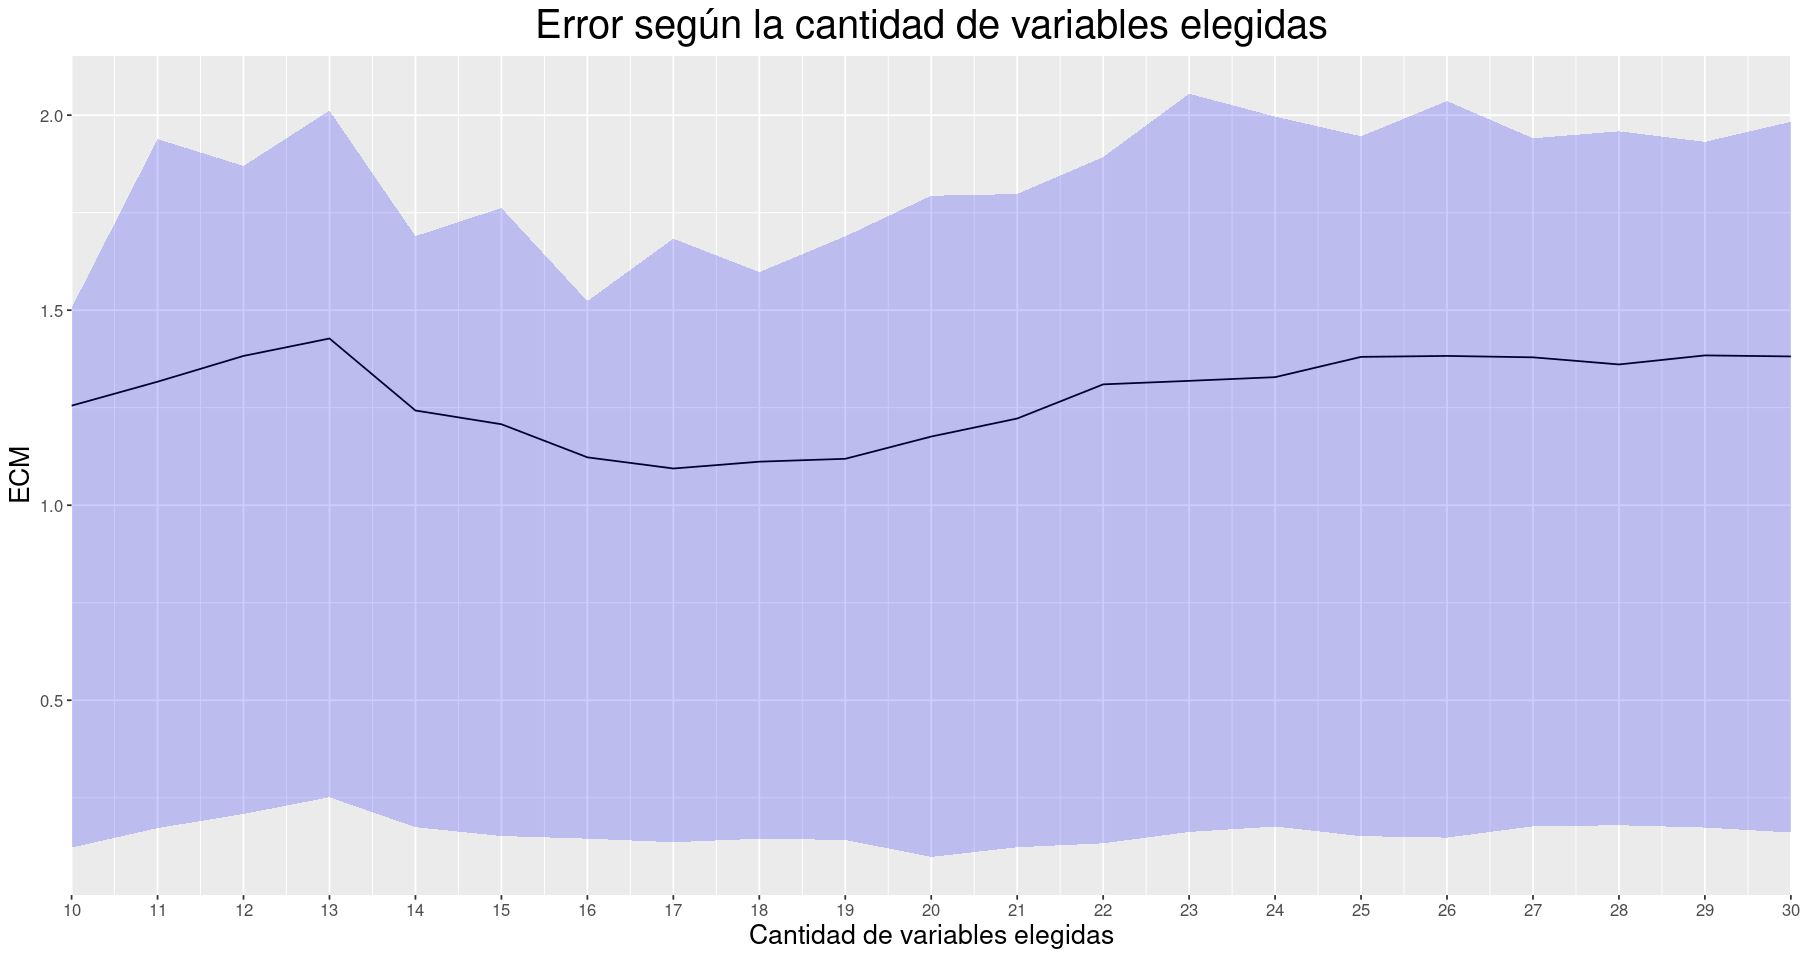

In [137]:
options(repr.plot.width=15, repr.plot.height=8)
theme_update(plot.title = element_text(hjust = 0.5, size = 24),
                          axis.text=element_text(size=10),
                          axis.title=element_text(size=16))

ggplot(a, aes(x=ind, y=mean)) +
    geom_line() +
    geom_ribbon(aes(ymin=q1, ymax=q3), fill="blue", alpha=0.2) +
    scale_x_continuous(breaks = seq(10, 30, by=1), expand = c(0, 0))+
    ggtitle("Error según la cantidad de variables elegidas") + 
    xlab("Cantidad de variables elegidas") + ylab("ECM")

Nos quedamos entonces con 17, pues es el valor con menor ECM por LOOCV

## Las variables elegidas

In [122]:
n = nrow(TRAIN_X)

forw <- regsubsets(Y~., data = TRAIN_DF, method = "forward", nvmax = 17

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“142  linear dependencies found”


In [200]:
vs <- names(which(summary(forw)$which[17, ])[2:18])
vs

[1] "V1"   "V6"   "V8"   "V36"  "V59"  "V70"  "V74"  "V88"  "V112" "V126"
[11] "V133" "V142" "V143" "V193" "V235" "V242" "V243"

In [201]:
SELECTED_TRAIN_X = TRAIN_DF[, vs]
SELECTED_TRAIN_DF = SELECTED_TRAIN_X
SELECTED_TRAIN_DF$Y = TRAIN_Y

# Modelo 1: regresion Lineal

In [203]:
# No escalamos los datos porque no hay regularizacion.
modelo1 <- lm(Y~., data = SELECTED_TRAIN_DF)

Y_pred = predict(modelo1, SELECTED_TRAIN_X)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(SELECTED_TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.539609005425229"


In [204]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    df_train = X[-i,]
    df_train$Y = TRAIN_Y[-i]
    
    X_test = X[i,]
    Y_test = TRAIN_Y[i]

    model <- lm(Y~.,  data = df_train)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.690052227476859"


In [205]:
p = ncol(SELECTED_TRAIN_X)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.956066368347469"


# Modelo 2: regresion Lineal Regularizada

In [207]:
setSeed()
n = nrow(SELECTED_TRAIN_X)
k = 5
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Escalador = integer(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

alphas <- seq(0, 1, 0.05)
lambdas <- logspace(-10, 3, 50)
escaladores <- c(StScaler(), MMScaler())


for (alpha in alphas) {
    for (lambda in lambdas) {
        for(s in 1:length(escaladores)){
            escalador = escaladores[[s]] 
            err = 0
            for (i in indices) {
                X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                Y_train = TRAIN_Y[-i]

                X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                Y_test = TRAIN_Y[i]

                model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
                Y_pred = predict(model, X_test_scaled)
                err = err + sum((Y_test - Y_pred)^2)
            }
            resultados = rbind(resultados, list(alpha, lambda, s, err/n))
        }
    }
    message(progreso(alpha, alphas))
}

colnames(resultados)  <- c("alpha", "lambda", "Escalador", "Error")

El progreso es del 4.8 %

El progreso es del 9.5 %

El progreso es del 14.3 %

El progreso es del 19 %

El progreso es del 23.8 %

El progreso es del 28.6 %

El progreso es del 33.3 %

El progreso es del 38.1 %

El progreso es del 42.9 %

El progreso es del 47.6 %

El progreso es del 52.4 %

El progreso es del 57.1 %

El progreso es del 61.9 %

El progreso es del 66.7 %

El progreso es del 71.4 %

El progreso es del 76.2 %

El progreso es del 81 %

El progreso es del 85.7 %

El progreso es del 90.5 %

El progreso es del 95.2 %

El progreso es del 100 %



In [208]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,alpha,lambda,Escalador,Error
,<dbl>,<dbl>,<int>,<dbl>
63,0,0.01676833,1,0.680737


##### Calculo del error por LOOCV

In [209]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
escalador = escaladores[[mejores_parametros$Escalador]]
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.688283385696551"


In [210]:
X_train_scaled <- as.matrix(escalador$fit_transform(X))
modelo2 <- glmnet(X_train_scaled, TRAIN_Y, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)

p = sum(modelo2$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.956178985393155"


# Modelo 3: árbol de regresión

# Modelo 4: KNN

# Modelo 5: regresión no paramétrica